In [1]:
import json
import pandas as pd

In [4]:
!pip install opencv-python

     ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
     ---------------------------------------- 0.2/39.0 MB 13.4 MB/s eta 0:00:03
      --------------------------------------- 0.8/39.0 MB 10.5 MB/s eta 0:00:04
     - -------------------------------------- 1.3/39.0 MB 10.5 MB/s eta 0:00:04
     - -------------------------------------- 1.9/39.0 MB 11.1 MB/s eta 0:00:04
     -- ------------------------------------- 2.4/39.0 MB 10.8 MB/s eta 0:00:04
     --- ------------------------------------ 2.9/39.0 MB 11.0 MB/s eta 0:00:04
     --- ------------------------------------ 3.2/39.0 MB 10.2 MB/s eta 0:00:04
     --- ------------------------------------ 3.7/39.0 MB 10.3 MB/s eta 0:00:04
     ---- ----------------------------------- 4.1/39.0 MB 10.0 MB/s eta 0:00:04
     ---- ----------------------------------- 4.2/39.0 MB 9.7 MB/s eta 0:00:04
     ---- ----------------------------------- 4.5/39.0 MB 9.0 MB/s eta 0:00:04
     ----- ---------------------------------- 5.0/


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


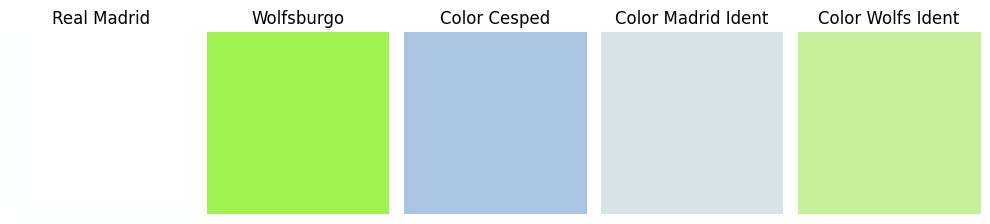

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Todos los colores en formato LAB (OpenCV)
TEAM_COLORS_LAB = {
    "Real Madrid": np.array([[[255, 127, 127]]], dtype=np.uint8),
    "Wolfsburgo":  np.array([[[224, 77, 196]]], dtype=np.uint8),
    
    "Color Cesped":      np.array([[[200, 125, 110]]], dtype=np.uint8),
    
    "Color Madrid Ident":      np.array([[[230, 123, 125]]], dtype=np.uint8),
    "Color Wolfs Ident":      np.array([[[230, 100, 165]]], dtype=np.uint8),
}

# Convertir de Lab (cv2) -> BGR -> RGB
colors_rgb = {
    name: cv2.cvtColor(val, cv2.COLOR_LAB2BGR)[0, 0][::-1]  # convierto a RGB
    for name, val in TEAM_COLORS_LAB.items()
}

# Mostrar con matplotlib
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for ax, (name, color) in zip(axes, colors_rgb.items()):
    ax.imshow(np.ones((100, 100, 3), dtype=np.uint8) * color)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

l -> 200
b -> 110
a -> 125

l-> 125
b -> 150
a -> 100

In [2]:
with open("tracks2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [3]:
exp = data[0]["track"]
players = exp["player"]

In [4]:
reformed_data = []
for n_frame, frame_tracks in enumerate(players):
    for tracker_id, player_dict in frame_tracks.items():
        row = {'frame': n_frame, 'tracker_id': tracker_id}
        row.update({
            "x1": player_dict["bbox"][0],
            "y1": player_dict["bbox"][1],
            "w": player_dict["bbox"][2] - player_dict["bbox"][0],
            "h": player_dict["bbox"][3] - player_dict["bbox"][1],
            "bbox_size": player_dict["bbox_size"],
            "confidence": player_dict["confidence"],
            "Real Madrid": player_dict["distances"]["Real Madrid"],
            "Wolfsburgo": player_dict["distances"]["Wolfsburgo"],
            "color_H": player_dict["shirt_color"][0],
            "color_S": player_dict["shirt_color"][1],
            "color_V": player_dict["shirt_color"][2],
            "team": player_dict["team"]
            } )
        reformed_data.append(row)

df = pd.DataFrame(reformed_data)
df = df.set_index(['frame', 'tracker_id'])
df

x1          y1          w           h  bbox_size  \
frame tracker_id                                                              
0     1            329.994690  492.321533  34.892487   77.333496       8085   
      2           1310.173828  444.692596  41.841187   72.407562       9198   
      3           1229.380249  429.818665  35.414917   71.943878       7560   
      4            534.124512  686.313721  43.202393   98.559265      12642   
      5            358.783722  720.085571  34.477783  105.921387      11130   
...                       ...         ...        ...         ...        ...   
199   34          1442.083496  656.842896  25.590454   72.627319       5475   
      51           669.817993  532.430786  20.041443   66.308899       3960   
      53           976.242188  738.881287  49.203369   75.375183      11172   
      66          1565.522461  537.036621  23.984985   65.235291       4680   
      74           215.430450  466.905518  14.391083   56.170166       2394   

                  confidence  Real Madrid  Wolfsburgo     color_H     color_S  \
frame tracker_id                                                                
0     1             0.869000   195.016263  190.307316  140.477627  100.885536   
      2             0.867242   190.258880  184.664490  126.915223   99.344576   
      3             0.857946   218.409460  234.175638  230.553738  122.981308   
      4             0.853259   190.279782  187.412327  135.543712  102.719325   
      5             0.851820   215.832014  231.259419  219.689713  126.639123   
...                      ...          ...         ...         ...         ...   
199   34            0.850174   185.659432  182.422063  105.558348  105.384201   
      51            0.842306   187.255467  182.627650  110.370370  102.894180   
      53            0.858932   198.906962  214.670239  192.134663  125.643392   
      66            0.841344   206.957557  224.257509  213.767327  124.752475   
      74            0.708078   186.583343  188.599500   68.030534  119.351145   

                     color_V         team  
frame tracker_id                           
0     1           161.910510   Wolfsburgo  
      2           160.014585   Wolfsburgo  
      3           124.635514  Real Madrid  
      4           156.178681   Wolfsburgo  
      5           127.359191  Real Madrid  
...                      ...          ...  
199   34          152.750449   Wolfsburgo  
      51          156.108466   Wolfsburgo  
      53          123.648379  Real Madrid  
      66          119.688119  Real Madrid  
      74          139.809160  Real Madrid  

[4024 rows x 12 columns]

<Axes: >

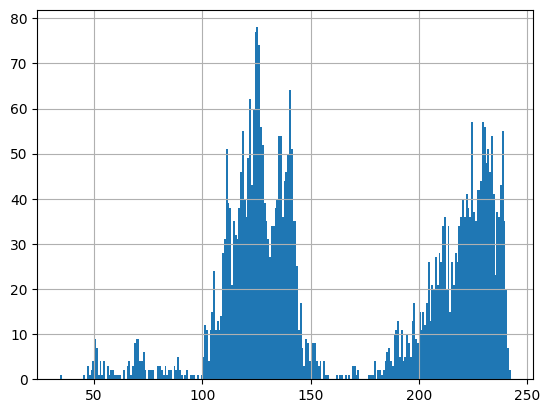

In [7]:
df["color_H"].hist(bins=250)

<Axes: >

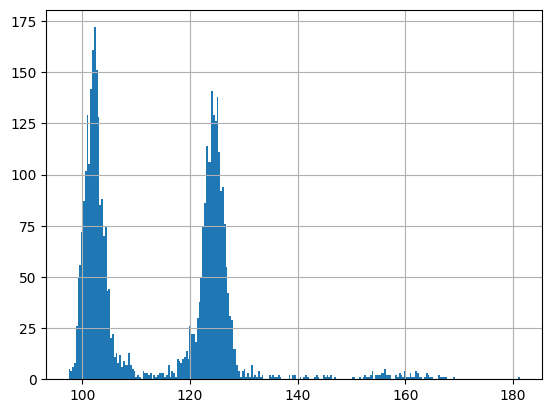

In [8]:
df["color_S"].hist(bins=250)

<Axes: >

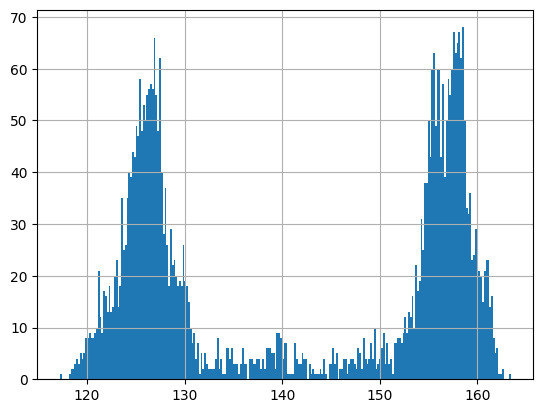

In [9]:
df["color_V"].hist(bins=250)

In [ ]:
madrid = [200, 110, 125]
wolfsburgo = [125, 150, 100]

In [ ]:
aux = df[df["color_H"] > 190 & df["color_H"] < 200]
aux = aux[aux["color_"]]

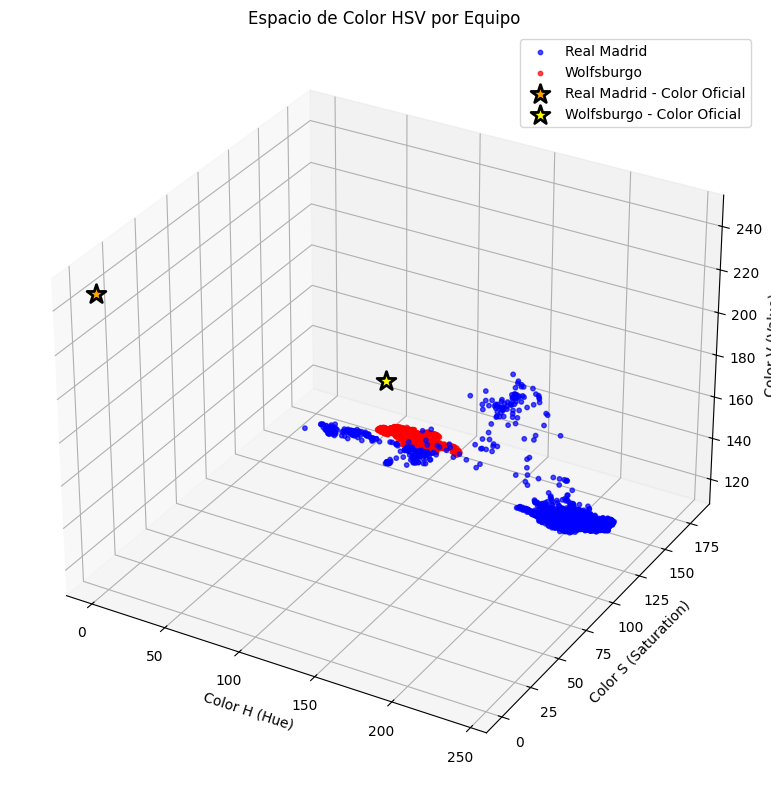

(None, <matplotlib.legend.Legend at 0x2273e8c4bb0>, None)

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

TEAM_COLORS = {  "Real Madrid": [0, 0, 245], "Wolfsburgo": [70, 150, 150]  }

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

mask = df["team"]=="Real Madrid"
ax.scatter(df[mask]["color_H"], df[mask]["color_S"], df[mask]["color_V"], c="blue", label="Real Madrid", s=10, alpha=0.7)
ax.scatter(df[~mask]["color_H"], df[~mask]["color_S"], df[~mask]["color_V"], c="red", label="Wolfsburgo", s=10, alpha=0.7)

ax.scatter([TEAM_COLORS["Real Madrid"][0]], [TEAM_COLORS["Real Madrid"][1]], [TEAM_COLORS["Real Madrid"][2]], 
           c="orange", label="Real Madrid - Color Oficial", s=200, marker='*', edgecolors='black', linewidth=2)
ax.scatter([TEAM_COLORS["Wolfsburgo"][0]], [TEAM_COLORS["Wolfsburgo"][1]], [TEAM_COLORS["Wolfsburgo"][2]], 
           c="yellow", label="Wolfsburgo - Color Oficial",  s=200, marker='*', edgecolors='black', linewidth=2)

ax.set_xlabel('Color H (Hue)'), ax.set_ylabel('Color S (Saturation)'), ax.set_zlabel('Color V (Value)'), ax.set_title('Espacio de Color HSV por Equipo')

plt.tight_layout(), plt.legend(), plt.show()

In [ ]:
!pip install plotly

     ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
     -- ------------------------------------- 0.6/9.9 MB 13.5 MB/s eta 0:00:01
     --------- ------------------------------ 2.3/9.9 MB 24.7 MB/s eta 0:00:01
     ----------------------- ---------------- 5.9/9.9 MB 41.8 MB/s eta 0:00:01
     ------------------------------------ --- 9.1/9.9 MB 48.1 MB/s eta 0:00:01
     ---------------------------------------- 9.9/9.9 MB 45.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/423.1 kB ? eta -:--:--
     ------------------------------------- 423.1/423.1 kB 25.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import plotly.express as px
import pandas as pd

# Preparar datos
plot_df = df.copy()
plot_df['team_color'] = plot_df['team'].apply(lambda x: 'blue' if x == 'Real Madrid' else 'red')

# Crear gráfico 3D interactivo
fig = px.scatter_3d(plot_df, 
                    x='color_H', 
                    y='color_S', 
                    z='color_V',
                    color='team',
                    color_discrete_map={'Real Madrid': 'blue', 'Wolfsburgo': 'red'},
                    title='Espacio de Color HSV por Equipo')

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed